# Hybrid CNN training data generated exactly through `data_utils.py`

This notebook no longer uses the custom six-parameter generator. It calls the
same functions and defaults used by the pasted `data_utils.py` code:

```python
load_drm(...)
bin_drm(...)
generate_spectrum_batch(...)
normalize_fit(...)
normalize_apply(...)
```

Therefore, the generated target spectrum uses the pasted code's five-parameter
PFF family:

\[
s(E)=a_1e^{-a_2E}
+a_3\exp\left[-\frac{(E-a_4)^2}{a_5}\right].
\]

The generation pipeline is:

1. Draw a balanced mixture of bump and no-bump spectra.
2. Forward-fold each spectrum through the binned DRM.
3. Add the configured detector-noise model.
4. Add synthetic saturation plateaus to a subset of responses.
5. L1-normalize the detector responses and spectrum targets.
6. Fit per-channel z-score statistics from bootstrap training data.
7. Split each 200-channel response into:
   - `fine_image`: `(4, 48, 1)`
   - `coarse_pixels`: `(8,)`

Because this notebook imports the generator from `data_utils.py`, its behavior
will stay synchronized with that file.

In [30]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from data_utils import (
    NOISE_GAIN,
    READ_FRAC,
    MULT_FRAC,
    SAT_FRACTION,
    SAT_CEIL_LOW,
    SAT_CEIL_HIGH,
    bin_drm,
    generate_spectrum_batch,
    load_drm,
    mev_bin_centers,
    normalize_apply,
    normalize_fit,
)

## Configuration

In [31]:
# Must point to the same 200 x 200 XLSX DRM used by data_utils.py.
XLSX_PATH = Path("res/drm/200x200.xlsx")

NUM_ENERGY_BINS = 50
N_SAMPLES = 100_000
VAL_SAMPLES = 5_000
NORM_BOOTSTRAP_SAMPLES = 10_000

BUMP_FRACTION = 0.75
MAX_BUMPS = 3
SEED = 42

# Explicitly copy the current data_utils defaults into this run.
# These are passed to generate_spectrum_batch rather than silently relying
# on defaults, so the saved metadata records the exact generation settings.
DATA_NOISE_GAIN = NOISE_GAIN
DATA_READ_FRAC = READ_FRAC
DATA_MULT_FRAC = MULT_FRAC
DATA_SAT_FRACTION = SAT_FRACTION

OUTPUT_PATH = Path(
    f"training_data_exact_data_utils_n{NUM_ENERGY_BINS}.npz"
)

assert 200 % NUM_ENERGY_BINS == 0
assert N_SAMPLES > 0
assert VAL_SAMPLES > 0
assert NORM_BOOTSTRAP_SAMPLES > 0

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Noise gain:", DATA_NOISE_GAIN)
print("Read fraction:", DATA_READ_FRAC)
print("Multiplicative fraction:", DATA_MULT_FRAC)
print("Saturation fraction:", DATA_SAT_FRACTION)
print("Saturation ceiling range:", SAT_CEIL_LOW, "to", SAT_CEIL_HIGH)

TensorFlow: 2.21.0
GPUs: []
Noise gain: 0.0
Read fraction: 0.0
Multiplicative fraction: 0.0
Saturation fraction: 0.0
Saturation ceiling range: 0.7 to 0.98


## Load and bin the DRM using `data_utils`

In [32]:
drm = load_drm(str(XLSX_PATH))
drm_binned = bin_drm(drm, NUM_ENERGY_BINS)



DRM_TRANSPOSE = tf.constant(
    drm_binned.T.astype(np.float32)
)  # shape: (n_bins, 200)


def l1_normalize_tensor(x):
    return x / tf.maximum(
        tf.reduce_sum(x, axis=1, keepdims=True),
        1e-8,
    )


def folded_detector_mse(y_true, y_pred):
    """
    Compare the detector responses produced by the true and
    predicted spectra.
    """

    true_response = tf.matmul(
        y_true,
        DRM_TRANSPOSE,
    )

    predicted_response = tf.matmul(
        y_pred,
        DRM_TRANSPOSE,
    )

    true_response = l1_normalize_tensor(
        true_response
    )

    predicted_response = l1_normalize_tensor(
        predicted_response
    )

    return tf.reduce_mean(
        tf.square(
            true_response - predicted_response
        ),
        axis=1,
    )


def spectrum_cdf_mse(y_true, y_pred):
    """
    Penalize energy being moved far from its correct location.

    This is more appropriate than ordinary bin-wise MSE alone because
    confusing neighboring energy bins is less severe than confusing
    widely separated bins.
    """

    true_cdf = tf.cumsum(
        y_true,
        axis=1,
    )

    predicted_cdf = tf.cumsum(
        y_pred,
        axis=1,
    )

    return tf.reduce_mean(
        tf.square(
            true_cdf - predicted_cdf
        ),
        axis=1,
    )


def combined_spectrum_loss(y_true, y_pred):
    spectrum_mse = tf.reduce_mean(
        tf.square(y_true - y_pred),
        axis=1,
    )

    detector_mse = folded_detector_mse(
        y_true,
        y_pred,
    )

    cdf_mse = spectrum_cdf_mse(
        y_true,
        y_pred,
    )

    # Mild smoothness penalty to reduce isolated bin spikes.
    total_variation = tf.reduce_mean(
        tf.abs(
            y_pred[:, 1:]
            - y_pred[:, :-1]
        ),
        axis=1,
    )

    return (
        spectrum_mse
        + 5.0 * detector_mse
        + 0.5 * cdf_mse
        + 1e-4 * total_variation
    )




energy_bins = mev_bin_centers(NUM_ENERGY_BINS).astype(np.float32)

print("Original DRM shape:", drm.shape)
print("Binned DRM shape:", drm_binned.shape)
print("Energy bins shape:", energy_bins.shape)
print(
    "Energy centers:",
    float(energy_bins[0]),
    "to",
    float(energy_bins[-1]),
    "MeV",
)

Original DRM shape: (200, 200)
Binned DRM shape: (200, 50)
Energy bins shape: (50,)
Energy centers: 0.5 to 49.5 MeV


## Fit normalization statistics exactly as in the hybrid training code

In [33]:
rng = np.random.default_rng(SEED)

X_boot, _ = generate_spectrum_batch(
    drm_binned,
    NORM_BOOTSTRAP_SAMPLES,
    rng,
    bump_fraction=BUMP_FRACTION,
    sat_fraction=DATA_SAT_FRACTION,
    noise_gain=DATA_NOISE_GAIN,
    read_frac=DATA_READ_FRAC,
    mult_frac=DATA_MULT_FRAC,
)

# X_boot is already L1-normalized by generate_spectrum_batch.
norm_mean, norm_std = normalize_fit(X_boot)

print("Bootstrap responses:", X_boot.shape)
print("Normalization mean:", norm_mean.shape)
print("Normalization std:", norm_std.shape)

del X_boot

Bootstrap responses: (10000, 200)
Normalization mean: (200,)
Normalization std: (200,)


## Generate an independent validation set

In [34]:
val_rng = np.random.default_rng(SEED + 1)

X_val_l1, y_val = generate_spectrum_batch(
    drm_binned,
    VAL_SAMPLES,
    val_rng,
    bump_fraction=BUMP_FRACTION,
    sat_fraction=DATA_SAT_FRACTION,
    noise_gain=DATA_NOISE_GAIN,
    read_frac=DATA_READ_FRAC,
    mult_frac=DATA_MULT_FRAC,
)

X_val_normalized = normalize_apply(
    X_val_l1,
    norm_mean,
    norm_std,
)

print("Validation detector responses:", X_val_l1.shape)
print("Validation spectrum targets:", y_val.shape)
print("First target sums:", y_val[:3].sum(axis=1))

Validation detector responses: (5000, 200)
Validation spectrum targets: (5000, 50)
First target sums: [1. 1. 1.]


## Generate the training set

In [35]:
generation_start = time.perf_counter()

X_train_l1, y_train = generate_spectrum_batch(
    drm_binned,
    N_SAMPLES,
    rng,
    bump_fraction=BUMP_FRACTION,
    sat_fraction=DATA_SAT_FRACTION,
    noise_gain=DATA_NOISE_GAIN,
    read_frac=DATA_READ_FRAC,
    mult_frac=DATA_MULT_FRAC,
)

X_train_normalized = normalize_apply(
    X_train_l1,
    norm_mean,
    norm_std,
)

print(
    f"Generated {N_SAMPLES:,} training examples in "
    f"{time.perf_counter() - generation_start:.1f} seconds."
)
print("Training detector responses:", X_train_l1.shape)
print("Training spectrum targets:", y_train.shape)
print("First target sums:", y_train[:3].sum(axis=1))

Generated 100,000 training examples in 1.5 seconds.
Training detector responses: (100000, 200)
Training spectrum targets: (100000, 50)
First target sums: [0.99999994 1.         1.        ]


## Split each 200-channel response into the hybrid model inputs

In [36]:
def split_detector_input(
    X: np.ndarray,
) -> dict[str, np.ndarray]:
    """
    Split without repeating any detector values.

    Channels 0--191:
        (N, 192) -> (N, 4, 48, 1)

    Channels 192--199:
        (N, 8)
    """
    X = np.asarray(X)

    if X.ndim != 2 or X.shape[1] != 200:
        raise ValueError(
            f"Expected shape (N, 200), received {X.shape}."
        )

    n = X.shape[0]

    return {
        "fine_image": X[:, :192].reshape(
            n,
            4,
            48,
            1,
        ).astype(np.float32),

        "coarse_pixels": X[:, 192:200].astype(np.float32),
    }


X_train_inputs = split_detector_input(X_train_normalized)
X_val_inputs = split_detector_input(X_val_normalized)

X_train_fine = X_train_inputs["fine_image"]
X_train_coarse = X_train_inputs["coarse_pixels"]

X_val_fine = X_val_inputs["fine_image"]
X_val_coarse = X_val_inputs["coarse_pixels"]

print("X_train_fine:", X_train_fine.shape)
print("X_train_coarse:", X_train_coarse.shape)
print("y_train:", y_train.shape)
print()
print("X_val_fine:", X_val_fine.shape)
print("X_val_coarse:", X_val_coarse.shape)
print("y_val:", y_val.shape)

X_train_fine: (100000, 4, 48, 1)
X_train_coarse: (100000, 8)
y_train: (100000, 50)

X_val_fine: (5000, 4, 48, 1)
X_val_coarse: (5000, 8)
y_val: (5000, 50)


## Inspect generated spectra and detector responses

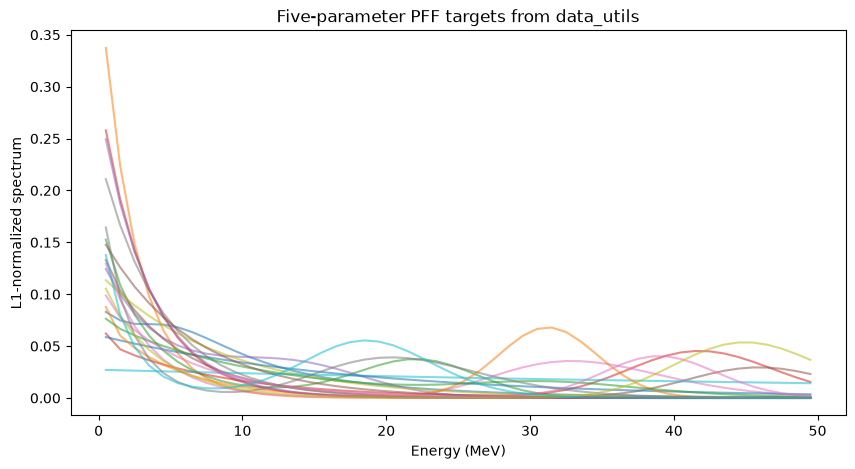

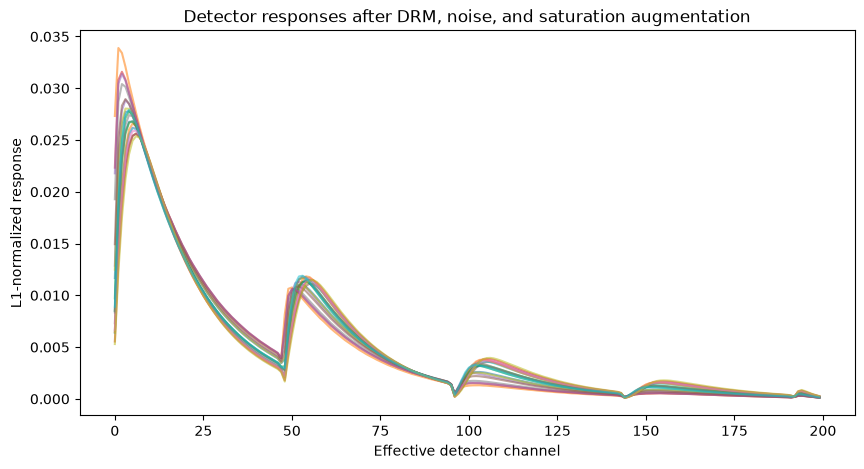

In [37]:
n_plot = min(20, N_SAMPLES)

plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(
        energy_bins,
        y_train[i],
        alpha=0.55,
    )
plt.xlabel("Energy (MeV)")
plt.ylabel("L1-normalized spectrum")
plt.title("Five-parameter PFF targets from data_utils")
plt.show()

plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(
        X_train_l1[i],
        alpha=0.55,
    )
plt.xlabel("Effective detector channel")
plt.ylabel("L1-normalized response")
plt.title(
    "Detector responses after DRM, noise, and saturation augmentation"
)
plt.show()

## Save the model-ready arrays

In [38]:
np.savez(
    OUTPUT_PATH,

    X_train_fine=X_train_fine,
    X_train_coarse=X_train_coarse,
    y_train=y_train,

    X_val_fine=X_val_fine,
    X_val_coarse=X_val_coarse,
    y_val=y_val,

    norm_mean=norm_mean,
    norm_std=norm_std,
    energy_bins=energy_bins,

    num_energy_bins=np.array(NUM_ENERGY_BINS, dtype=np.int32),
    bump_fraction=np.array(BUMP_FRACTION, dtype=np.float32),

    noise_gain=np.array(DATA_NOISE_GAIN, dtype=np.float32),
    read_frac=np.array(DATA_READ_FRAC, dtype=np.float32),
    mult_frac=np.array(DATA_MULT_FRAC, dtype=np.float32),

    sat_fraction=np.array(DATA_SAT_FRACTION, dtype=np.float32),
    sat_ceil_low=np.array(SAT_CEIL_LOW, dtype=np.float32),
    sat_ceil_high=np.array(SAT_CEIL_HIGH, dtype=np.float32),
)

print(f"Saved: {OUTPUT_PATH.resolve()}")

Saved: C:\Users\aayan\OneDrive\Documents\GitHub\SAS-Analysis-Laser\training_data_exact_data_utils_n50.npz


## Train the hybrid model and save the best epoch

In [39]:
from train_cnn_hybrid import build_model

MAX_EPOCHS = 200
BATCH_SIZE = 256

BEST_MODEL_PATH = (
    f"best_model_exact_data_utils_n{NUM_ENERGY_BINS}.keras"
)

HISTORY_CSV_PATH = (
    f"training_history_exact_data_utils_n{NUM_ENERGY_BINS}.csv"
)

HISTORY_JSON_PATH = (
    f"training_history_exact_data_utils_n{NUM_ENERGY_BINS}.json"
)

SUMMARY_PATH = (
    f"training_summary_exact_data_utils_n{NUM_ENERGY_BINS}.json"
)

assert y_train.shape[1] == NUM_ENERGY_BINS
assert y_val.shape[1] == NUM_ENERGY_BINS

tf.random.set_seed(SEED)

model = build_model(NUM_ENERGY_BINS)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2e-4,
        clipnorm=1.0,
    ),
    loss=combined_spectrum_loss,
    metrics=[
        "mae",
        folded_detector_mse,
    ],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_folded_detector_mse",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_folded_detector_mse",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_folded_detector_mse",
        mode="min",
        patience=20,
        min_delta=1e-8,
        restore_best_weights=True,
        verbose=1,
    ),
]



history = model.fit(
    {
        "fine_image": X_train_fine,
        "coarse_pixels": X_train_coarse,
    },
    y_train,

    validation_data=(
        {
            "fine_image": X_val_fine,
            "coarse_pixels": X_val_coarse,
        },
        y_val,
    ),

    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

best_epoch_index = int(
    np.argmin(history.history["val_loss"])
)

best_epoch = best_epoch_index + 1
best_val_loss = float(
    history.history["val_loss"][best_epoch_index]
)
best_val_mae = float(
    history.history["val_mae"][best_epoch_index]
)

with open(HISTORY_JSON_PATH, "w") as file:
    json.dump(
        history.history,
        file,
        indent=2,
    )

pd.DataFrame(history.history).to_csv(
    HISTORY_CSV_PATH,
    index_label="epoch_index",
)

training_summary = {
    "num_energy_bins": NUM_ENERGY_BINS,
    "training_generator": "data_utils.generate_spectrum_batch",
    "epochs_completed": len(history.history["loss"]),
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "best_validation_mae": best_val_mae,
    "best_model_path": BEST_MODEL_PATH,
    "bump_fraction": BUMP_FRACTION,
    "noise_gain": float(DATA_NOISE_GAIN),
    "read_frac": float(DATA_READ_FRAC),
    "mult_frac": float(DATA_MULT_FRAC),
    "sat_fraction": float(DATA_SAT_FRACTION),
}

with open(SUMMARY_PATH, "w") as file:
    json.dump(
        training_summary,
        file,
        indent=2,
    )

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Best validation MAE:", best_val_mae)
print("Best model:", BEST_MODEL_PATH)

Epoch 1/200
 95/391 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - folded_detector_mse: 7.0549e-07 - loss: 0.0157 - mae: 0.0213

KeyboardInterrupt: 

## Expected shapes

With the default configuration:

| Array | Shape |
|---|---:|
| `X_train_fine` | `(100000, 4, 48, 1)` |
| `X_train_coarse` | `(100000, 8)` |
| `y_train` | `(100000, 50)` |
| `X_val_fine` | `(5000, 4, 48, 1)` |
| `X_val_coarse` | `(5000, 8)` |
| `y_val` | `(5000, 50)` |

This notebook uses the exact generator implemented by the local
`data_utils.py`. It does **not** retain the previous six-parameter target
equation.